## CS 896 – Data Science Capstone  
### Surface Water and Drinking Water Contaminants  
### Team 10 

**Project goal:** Analyze contaminant patterns in Kansas drinking water and surface water data, identify important contaminants, and evaluate whether surface water contamination can be linked to community drinking water systems.

### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Loading the Drinking Water Dataset

In this step, we load the original CCR drinking water dataset. This dataset contains contaminant names, reported values, units, MCL values, years, and source-system information.

In [2]:
drinking_file = "combined_ccrs_long.csv"

df_raw = pd.read_csv(drinking_file)

print("Original drinking water dataset shape:", df_raw.shape)
display(df_raw.head())
display(df_raw.info())

Original drinking water dataset shape: (16106, 10)


,source,Contaminant,Collection.Date,Highest.Value,Range..low.high.,Unit,MCL,MCLG,Typical.Source,Year
0,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,ARSENIC,1/10/2018,1.1,1.1,ppb,10,0,Erosion of natural deposits,2019
1,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,ATRAZINE,8/20/2018,0.74,0.74,ppb,3,3,Runoff from herbicide used on row crops,2019
2,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,BARIUM,1/10/2018,0.12,0.12,ppm,2,2,Discharge from metal refineries,2019
3,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,CHROMIUM,1/10/2018,5.2,5.2,ppb,100,100,Discharge from steel and pulp mills,2019
4,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,FLUORIDE,1/10/2018,0.35,0.35,ppm,4,4,Natural deposits; Water additive which promote...,2019


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16106 entries, 0 to 16105
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   source            16106 non-null  object
 1   Contaminant       16105 non-null  object
 2   Collection.Date   16101 non-null  object
 3   Highest.Value     16101 non-null  object
 4   Range..low.high.  16099 non-null  object
 5   Unit              16101 non-null  object
 6   MCL               16100 non-null  object
 7   MCLG              16082 non-null  object
 8   Typical.Source    16025 non-null  object
 9   Year              16106 non-null  int64 
dtypes: int64(1), object(9)
memory usage: 1.2+ MB


None

### Initial Data Review

Before cleaning, we check column names, missing values, duplicate records, and the different units used in the dataset.

In [3]:
print("Column names:")
print(df_raw.columns.tolist())

print("\nMissing values:")
display(df_raw.isna().sum())

print("\nDuplicate rows:")
print(df_raw.duplicated().sum())

print("\nUnit values:")
display(df_raw["Unit"].value_counts(dropna=False))

print("\nTop contaminants before cleaning:")
display(df_raw["Contaminant"].value_counts().head(15))

Column names:
['source', 'Contaminant', 'Collection.Date', 'Highest.Value', 'Range..low.high.', 'Unit', 'MCL', 'MCLG', 'Typical.Source', 'Year']

Missing values:


source               0
Contaminant          1
Collection.Date      5
Highest.Value        5
Range..low.high.     7
Unit                 5
MCL                  6
MCLG                24
Typical.Source      81
Year                 0
dtype: int64


Duplicate rows:
0

Unit values:


Unit
ppm        8237
ppb        7508
PCI/L       240
MG/L         89
µg/l          8
5             6
NaN           5
pCi/l         4
ppt           3
15            2
Unit          1
UMHO/CM       1
LANG          1
PH            1
Name: count, dtype: int64


Top contaminants before cleaning:


Contaminant
BARIUM                           3086
FLUORIDE                         2627
SELENIUM                         2408
NITRATE                          2406
CHROMIUM                         2057
ARSENIC                          2008
ATRAZINE                          846
COMBINED RADIUM (-226 & -228)     141
METHOXYCHLOR                       75
GROSS ALPHA, INCL. RADON & U       48
NITRATE-NITRITE                    42
XYLENES, TOTAL                     41
RADIUM-228                         28
CARBON TETRACHLORIDE               28
2,4-D                              27
Name: count, dtype: int64

### Clean Drinking Water Dataset

The drinking water data has values in different units such as ppb, ppm, and mg/L. Since ppb is easier to compare across contaminants, all concentration values are converted to ppb.

In [4]:
df = df_raw.copy()

# Clean column names without changing the meaning of the original data
df.columns = df.columns.str.strip()

# Standardize contaminant names and unit values
df["Contaminant"] = df["Contaminant"].astype(str).str.strip().str.upper()
df["Unit"] = df["Unit"].astype(str).str.strip().str.lower()

# Convert date column
df["Collection.Date"] = pd.to_datetime(df["Collection.Date"], errors="coerce")

# Use Year column if available, otherwise extract from date
if "Year" in df.columns:
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
else:
    df["Year"] = df["Collection.Date"].dt.year

df["Year_num"] = df["Year"]

# Function to handle values like <0.5, ND, and regular numbers
def clean_numeric_value(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip()
    
    if value.upper() in ["ND", "N/D", "NON-DETECT", "NON DETECT", "NA", "NAN", ""]:
        return np.nan
    
    # For values like <0.5, we keep the numeric part as 0.5
    match = re.search(r"[-+]?\d*\.?\d+", value)
    if match:
        return float(match.group())
    
    return np.nan

df["Highest.Value"] = df["Highest.Value"].apply(clean_numeric_value)
df["MCL"] = df["MCL"].apply(clean_numeric_value)

# Convert concentration values to ppb
def convert_to_ppb(value, unit):
    if pd.isna(value):
        return np.nan
    
    unit = str(unit).lower().strip()
    
    if unit in ["ppb", "ug/l", "µg/l", "ug/liter", "micrograms/liter"]:
        return value
    elif unit in ["ppm", "mg/l", "mg/liter", "milligrams/liter"]:
        return value * 1000
    else:
        return value

df["Highest_ppb"] = df.apply(lambda row: convert_to_ppb(row["Highest.Value"], row["Unit"]), axis=1)
df["MCL_ppb"] = df.apply(lambda row: convert_to_ppb(row["MCL"], row["Unit"]), axis=1)

# Remove duplicate rows
before_duplicates = df.shape[0]
df = df.drop_duplicates()
after_duplicates = df.shape[0]

print("Rows before duplicate removal:", before_duplicates)
print("Rows after duplicate removal:", after_duplicates)
print("Duplicates removed:", before_duplicates - after_duplicates)

# Keep rows needed for analysis
df = df.dropna(subset=["Contaminant", "Highest_ppb", "Year"])

print("Cleaned drinking water dataset shape:", df.shape)
display(df.head())

Rows before duplicate removal: 16106
Rows after duplicate removal: 16106
Duplicates removed: 0
Cleaned drinking water dataset shape: (16100, 13)


,source,Contaminant,Collection.Date,Highest.Value,Range..low.high.,Unit,MCL,MCLG,Typical.Source,Year,Year_num,Highest_ppb,MCL_ppb
0,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,ARSENIC,2018-01-10,1.10,1.1,ppb,10.0,0,Erosion of natural deposits,2019,2019,1.10,10.0
1,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,ATRAZINE,2018-08-20,0.74,0.74,ppb,3.0,3,Runoff from herbicide used on row crops,2019,2019,0.74,3.0
2,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,BARIUM,2018-01-10,0.12,0.12,ppm,2.0,2,Discharge from metal refineries,2019,2019,120.00,2000.0
3,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,CHROMIUM,2018-01-10,5.20,5.2,ppb,100.0,100,Discharge from steel and pulp mills,2019,2019,5.20,100.0
4,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,FLUORIDE,2018-01-10,0.35,0.35,ppm,4.0,4,Natural deposits; Water additive which promote...,2019,2019,350.00,4000.0


### Create Exceedance and Outlier Variables

This step creates two important project variables:

- `Exceed_MCL`: identifies whether a reported contaminant value is above its regulatory limit.
- `Outlier_Flag`: identifies unusually high or low values using the IQR method within each contaminant.

In [5]:
# MCL exceedance flag
df["Exceed_MCL"] = np.where(
    (df["MCL_ppb"].notna()) & (df["Highest_ppb"] > df["MCL_ppb"]),
    1,
    0
)

# IQR outlier flag by contaminant
df["Outlier_Flag"] = 0

for contaminant in df["Contaminant"].unique():
    temp = df[df["Contaminant"] == contaminant]
    
    q1 = temp["Highest_ppb"].quantile(0.25)
    q3 = temp["Highest_ppb"].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    df.loc[
        (df["Contaminant"] == contaminant) &
        ((df["Highest_ppb"] < lower_bound) | (df["Highest_ppb"] > upper_bound)),
        "Outlier_Flag"
    ] = 1

print("Feature engineering completed.")
display(df[["Contaminant", "Highest_ppb", "MCL_ppb", "Exceed_MCL", "Outlier_Flag"]].head())

Feature engineering completed.


,Contaminant,Highest_ppb,MCL_ppb,Exceed_MCL,Outlier_Flag
0,ARSENIC,1.10,10.0,0,0
1,ATRAZINE,0.74,3.0,0,0
2,BARIUM,120.00,2000.0,0,0
3,CHROMIUM,5.20,100.0,0,0
4,FLUORIDE,350.00,4000.0,0,0


### Drinking Water EDA
Here we identify the most frequently reported contaminants. This helps decide which contaminants have enough observations for trend analysis.

Contaminant
BARIUM                           3086
FLUORIDE                         2627
SELENIUM                         2408
NITRATE                          2406
CHROMIUM                         2057
ARSENIC                          2008
ATRAZINE                          846
COMBINED RADIUM (-226 & -228)     141
METHOXYCHLOR                       75
GROSS ALPHA, INCL. RADON & U       48
Name: count, dtype: int64

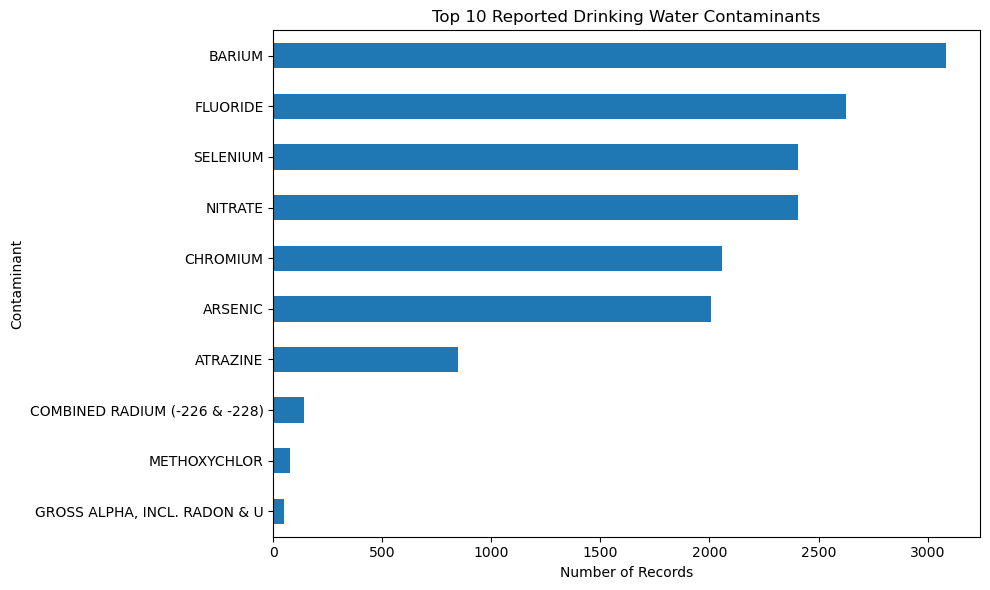

In [6]:
top_contaminants = df["Contaminant"].value_counts().head(10)

display(top_contaminants)

plt.figure(figsize=(10, 6))
top_contaminants.sort_values().plot(kind="barh")
plt.title("Top 10 Reported Drinking Water Contaminants")
plt.xlabel("Number of Records")
plt.ylabel("Contaminant")
plt.tight_layout()
plt.savefig("top_contaminants.png", dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

The frequency distribution shows that Barium, Fluoride, Selenium, Nitrate, and Chromium are the most commonly reported contaminants in the dataset. These contaminants appear significantly more often than the others, which indicates that they have sufficient data available for further analysis.

This is important because contaminants with a higher number of observations provide more reliable patterns for trend analysis, exceedance evaluation, and comparison. Based on this result, the top five contaminants were selected for deeper analysis in the next steps.